# Week 3 quiz - Social Networks

# Imports

In [99]:
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from social_networks.describe import describe_graph
import social_networks.visualize as viz
import social_networks.page_rank as pg_rnk

In [ ]:
%matplotlib widget

%load_ext autoreload
%autoreload 2

# 1 ✅ degree centrality of node $D$

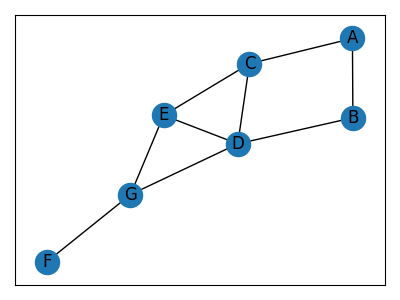

In [109]:
edges = [('A', 'B'),
         ('A', 'C'),
         ('B', 'D'),
         ('C', 'D'),
         ('C', 'E'),
         ('D', 'E'),
         ('D', 'G'),
         ('E', 'G'),
         ('G', 'F')]
g = nx.Graph()
g.add_edges_from(edges)
plt.clf()
nx.draw_networkx(g)
plt.show()

$$
C_\text{indeg}(\nu) = \frac{d_\nu^{\text{in}}}{|N| - 1}
$$
$N =$ set of nodes in the network  
$d_\nu ^\text{in} = $ the in-degree of node $\nu$


$N = 7$ \
$d_\nu = 4$ \
$C = \frac{4}{7 - 1} = 0.67$

In [67]:
nx.degree_centrality(G=g)

{'A': 0.3333333333333333,
 'B': 0.3333333333333333,
 'C': 0.5,
 'D': 0.6666666666666666,
 'E': 0.5,
 'G': 0.5,
 'F': 0.16666666666666666}

# 2 ❌✅ Closeness centrality of $G$

\begin{aligned}
C_\text{close}(\nu) &= \frac{|N| - 1} {\sum_{u \in N \setminus \nu} d(\nu, u)} \\
&= \frac{\text{Num. of nodes} - 1} {\text{Sum of the distance to all nodes from } \nu}
\end{aligned}

The max value $= 1$ occurs when the node $\nu$ is connected to every node, so 
$$d(\nu, u) = 1; \forall u$$

numer = 7 - 1 \

distances

G-A: 3 \
G-B: 2 \
G-C: 2 \
G-D: 1 \
G-E: 1 \
G-F: 1 

sum = 10

$C_\text{close}(G) = \frac{7 - 1}{10} = 0.6$

I thought I put $0.6$ the 1st time. Maybe I hit the wrong answer?

In [108]:
nx.closeness_centrality(g)

{'A': 0.46153846153846156,
 'B': 0.5454545454545454,
 'C': 0.6,
 'D': 0.75,
 'E': 0.6666666666666666,
 'G': 0.6,
 'F': 0.4}

# 3 ✅ Normalized betweenness centrality of $G$

$$
C_\text{btw}(\nu) = \sum_{s, t \in N}  \frac{\sigma_{s,t}(\nu)} {\sigma_{s,t}}
$$
$\sigma_{s,t} = $ Number of shortest paths between nodes $s$ and $t$   
$\sigma_{s,t}(\nu) = $ Number of shortest paths between nodes $s$ and $t$ that pass through $\nu$

Normalize by dividing by the number of pairs of nodes in the graph (excluding $\nu$)  
$N$ = number of nodes including $\nu$

\begin{aligned}
\text{undirected graphs} &: \frac{1}{2}\Bigl(|N| - 1\Bigr)\Bigl(|N| - 2\Bigr) \\
\text{directed graphs} &: \Bigl(|N| - 1\Bigr)\Bigl(|N| - 2\Bigr)
\end{aligned}

F-A: sp=4, 3 \
F-B: sp=3, 1 \
F-C: sp=3, 2 \
F-D: sp=2, 1 \
F-E: sp=2, 1 \

$\sum = 3/3 + 1/1 + 2/2 + 1/1 + 1/1 = 5$

Normalization factor $= \frac{1}{2}(|N|-1)(|N|-2) = \frac{1}{2} \times 5 \times 6 = 15$

$C_\text{btw}(G) = \frac{5}{15} = 0.33$




In [30]:
nx.betweenness_centrality(g, normalized=True)

{'A': 0.03333333333333333,
 'B': 0.07777777777777777,
 'C': 0.18888888888888888,
 'D': 0.38888888888888884,
 'E': 0.1111111111111111,
 'G': 0.3333333333333333,
 'F': 0.0}

# 4 ❌✅ Betweeness centrality of edge $(G, F)$ 
(no normalization)

$$
C_\text{btw}(e) = \sum_{s, t \in N}  \frac{\sigma_{s,t}(e)} {\sigma_{s,t}}
$$
$\sigma_{s,t} = $ Number of shortest paths between nodes $s$ and $t$   
$\sigma_{s,t}(e) = $ Number of shortest paths between nodes $s$ and $t$ that pass through edge $e$

## 1st time (wrong)

All paths will pass through edge $(G, F)$

So, $\sigma_{s,t}(e) = \sigma_{s,t}$ for every $s=F$,
and $\sigma_{s,t}(e) = 0$ when $s \ne F$

So, just count the number of nodes $A-E = 5$

## 2nd time

| Path | shortest | $\sigma_{s,t}(e)$ | $\sigma_{s,t}$| ratio|
|----|----|----|----|----|
| A-B| 1| 0 |1|0|
|A-C | 1|0|1|0|
|A-D| 2|0|2|0|
|A-E| 2|0|1|0|
|A-F| 4 | 3 | 3| 1|
|A-G| 3| 0| 3| 0|
|B-C| 2| 0| 2| 0|
|B-D| 1| 0| 1| 0|
|B-E| 2| 0| 1| 0|
|B-F| 3| 1| 1| 1|
|B-G| 2| 0| 1| 0|
|C-D| 1| 0| 1| 0|
|C-E| 1| 0| 1| 0|
|C-F| 3| 2| 2| 1|
|C-G| 2| 0| 2| 0|
|D-E| 1| 0| 1| 0|
|D-F| 2| 1| 1| 1|
|D-G| 1| 0| 1| 0|
|E-F| 2| 1| 1| 1|
|E-G| 1| 0| 1| 0|
|F-G| 1| 1| 1| 1|

The 1st time around, I assumed $G$ shouldn't be an end point.
The logic from before is correct, but I should've counted nodes $A-E, G$

New answer: 6


From the `networkx` documentation

$c_B(e) =\sum_{s,t \in V} \frac{\sigma(s, t|e)}{\sigma(s, t)}$

where $V$ is the set of nodes, $\sigma(s, t)$ is the number of shortest $(s, t)$-paths, and $\sigma(s, t|e)$ is the number of those paths passing through edge $e$

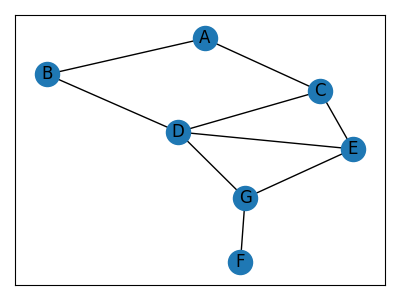

In [70]:
plt.clf()
nx.draw_networkx(g)
plt.show()

In [32]:
nx.edge_betweenness_centrality(g, normalized=False)

{('A', 'B'): 2.666666666666666,
 ('A', 'C'): 4.333333333333333,
 ('B', 'D'): 5.666666666666667,
 ('C', 'D'): 3.666666666666666,
 ('C', 'E'): 3.666666666666666,
 ('D', 'E'): 2.0,
 ('D', 'G'): 6.333333333333333,
 ('E', 'G'): 3.6666666666666665,
 ('G', 'F'): 6.0}

# 5 ❌✅ Select all True statements

Select all True statements. 

* T - The assumption of degree centrality is that important nodes have more connections.

* T - The closeness centrality of a node describes how far the node is from others.

* T - We can use subsets of node-pairs to approximate betweenness centrality. 

* F - In directed networks, in-degree and out-degree centrality of a node are always the same.

* F - The node with highest betwenness centrality in a network also has the highest closeness centrality. 


# 6 ✅ Select all True statements about Page Rank
(PR) and HITS in directed networks

Select all True statements about Page Rank (PR) and HITS in directed networks.

* F - Nodes with high in-degree centrality have higher PRs than nodes with low in-degree centrality.

* T - Adding in-links of a node will never decrease its PR.

* F - Adding out-links of a node will always decrease its PR.    

* F - Nodes that have outgoing edges to good hubs are good authorities, and nodes that have incoming edges from good authorities are good hubs. 

* T - The authority and hub score of each node is obtained by computing multiple iterations of HITS algorithm and both scores of most networks are convergent.


# 7 ✅ $\alpha$ in PageRank

Given the network below, which value of alpha (damping parameter) listed below in the
NetworkX function pagerank maximizes the
PageRank of node D?


High $\alpha$ means it'll be more likely to be "stuck" between $C$ and $D$

Answer $0.95$

# 8 ✅ Basic Page Rank (1 step)

Basic Page Rank of node $C$ at $k=1$

A: 1/4; 1/4 \
B: 1/4; 1/8 \
C: 1/4; 1/8 + 1/4 + 1/4 \
D: 1/4; 0 

C : 5/8

In [95]:
edges_a_d = [("A", "B"), ("A", "C"), ("B", "C"), ("C", "A"), ("D", "C")]
g10 = nx.MultiDiGraph()
g10.add_edges_from(edges_a_d)

[0, 0, 0, 0, 0]

In [ ]:
# ### Moved to `visualization.py`
plt.figure(figsize=(4, 3))

pos = nx.spring_layout(g10, seed=1)

nx.draw_networkx_nodes(g10, pos=pos, node_size=1500, node_color="skyblue")
nx.draw_networkx_labels(g10, pos, font_size=16, font_color="white", font_weight="bold")
nx.draw_networkx_edges(
    g10,
    pos=pos,
    arrowstyle="-|>",
    arrowsize=20,
    edge_color="black",
    connectionstyle="arc3, rad=0.2",
    min_source_margin=15,
    min_target_margin=20,  # to end arrows away from the center of the node
)
plt.axis("off")
plt.tight_layout()
plt.show()
g8 = nx.MultiDiGraph()
g8.add_edges_from(edges_a_d)

viz.draw_big_multi_directed(g8)

In [101]:
pr, history = pg_rnk.pagerank_steps_with_history(G=g8, k=1, alpha=1)
pr

{'A': 0.25, 'B': 0.125, 'C': 0.625, 'D': 0.0}

In [103]:
pd.DataFrame(history).T

,0,1
A,0.25,0.250
B,0.25,0.125
C,0.25,0.625
D,0.25,0.000


# 9 ✅ HITS algorithm (2 steps)

1. Assign each node an authority and hub score of $1$.
2. Apply the **Authority Update Rule**: each node’s *authority* score is the sum of *hub* scores of each node that *points to it*.
3. Apply the **Hub Update Rule**: each node’s *hub* score is the sum of *authority* scores of each node that *it points to*.
4. **Nomalize Authority and Hub scores**: 
\begin{aligned}
\text{auth}(j) &= \frac{\text{auth}(j)}{\sum_{i \in N} \text{auth}(i)} \\
\text{hub}(j) &= \frac{\text{hub}(j)}{\sum_{i \in N} \text{hub}(i)}
\end{aligned}
5. Repeat $k$ times.

In [9]:
nodes = ["A", "B", "C", "D"]
auth_0 = [1, 1, 1, 1]
hub_0 = [1, 1, 1, 1]

import pandas as pd
import numpy as np

df_hits = pd.DataFrame({
    "node":nodes,
    "auth_0": auth_0,
    "hub_0": hub_0
})

df_hits.set_index("node", inplace=True)
df_hits

,auth_0,hub_0
node,,
A,1,1
B,1,1
C,1,1
D,1,1


In [12]:
auth_1 = np.array([1, 1, 3, 0])
hub_1 = np.array([2, 1, 1, 1])
norm_auth_1 = 5
norm_hub_1 = 5


df_hits["auth_1"] = auth_1 / norm_auth_1
df_hits["hub_1"] = hub_1 / norm_hub_1
df_hits

,auth_0,hub_0,auth_1,hub_1
node,,,,
A,1,1,0.2,0.4
B,1,1,0.2,0.2
C,1,1,0.6,0.2
D,1,1,0.0,0.2


In [13]:
auth_2 = np.array([0.2, 0.4, 0.8, 0])
hub_2 = np.array([0.8, 0.6, 0.2, 0.6])

df_hits["auth_2"] = auth_2 / np.sum(auth_2)
df_hits["hub_2"] = hub_2 / np.sum(hub_2)
df_hits

,auth_0,hub_0,auth_1,hub_1,auth_2,hub_2
node,,,,,,
A,1,1,0.2,0.4,0.142857,0.363636
B,1,1,0.2,0.2,0.285714,0.272727
C,1,1,0.6,0.2,0.571429,0.090909
D,1,1,0.0,0.2,0.000000,0.272727


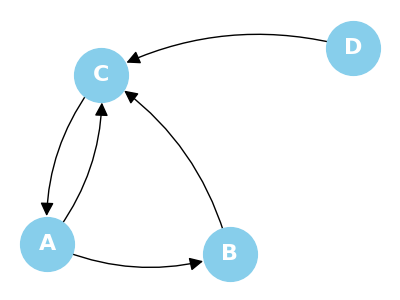

In [104]:
viz.draw_big_multi_directed(g8)

In [107]:
list(g8.predecessors("A"))

['C']

In [106]:
list(g8.predecessors("C"))

['A', 'B', 'D']

# 10 ❌✅ Which is not true?

Based on the network below, which of the following is NOT True? Check all that apply

Mark the F statements on the quiz

* T - At step k (k>=1), node A’s basic PR is always the same as node C’s basic PR at step k-1.

* T - Node D’s basic PR at step k (k>=1) is always 0.    

* T - At each step, the sum of all nodes’ basic PR is always 1.

* F - Node D’s authority and hub score after k iterations (k>=1) are always 0.
